In [1]:
from pathlib import Path

# General helpful packages for data analysis and visualization
import pandas as pd
import scanpy as sc
import seaborn as sns
from muon import atac as ac  # the module containing function for scATAC data processing
import matplotlib.pyplot as plt
import muon as mu

import sys
PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")
SRC_DIR = str(PROJECT_DIR / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
    
import multiomic_transformer.utils.muon_preprocessing as muon_prep

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/")

cell_type="mESC"
sample_name="E7.5_rep1"
experiment_name=f"{cell_type}_{sample_name}_tutorial"
organism_code="mm10"

tss_path=f"{PROJECT_DIR}/data/genome_data/genome_annotation/{organism_code}/gene_tss.bed"
tf_list_path=""

raw_dataset_name = "mESC_10x_raw"

SAMPLE_RAW_DATA_DIR=Path(f"{DATA_DIR}/RAW_DATA/{raw_dataset_name}/{sample_name}")
SAMPLE_PROCESSED_DATA_DIR=Path(f"{DATA_DIR}/PROCESSED_DATA/{experiment_name}/{sample_name}")

FRAG_PATH = SAMPLE_RAW_DATA_DIR / "fragments.sorted.tsv.gz"

RNA_COUNT_FILE=""
ATAC_COUNT_FILE=""

RAW_H5_FILE=""

In [3]:
tss_path = Path(tss_path)
rna_count_file = Path(RNA_COUNT_FILE) if RNA_COUNT_FILE else None
atac_count_file = Path(ATAC_COUNT_FILE) if ATAC_COUNT_FILE else None
raw_h5_file = Path(RAW_H5_FILE) if RAW_H5_FILE else None
tf_list_file = Path(tf_list_path) if tf_list_path else None
frag_path = Path(FRAG_PATH) if FRAG_PATH else None

In [4]:
filtering_setting_df = pd.read_csv(PROJECT_DIR / "data" /"qc_filtering_settings.tsv", sep="\t")
sample_filtering_settings = filtering_setting_df[filtering_setting_df["Sample"] == sample_name]    

# ----- RNA QC thresholds -----
MIN_CELLS_PER_GENE = muon_prep.get_threshold(sample_filtering_settings, "Min Cells per Gene")
MIN_GENES_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Min Genes per Cell")
MAX_GENES_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Max Genes per Cell")
MIN_TOTAL_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Min Total Counts")
MAX_TOTAL_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Max Total Counts")
MAX_PCT_COUNTS_MT = muon_prep.get_threshold(sample_filtering_settings, "Max Pct MT")

# ----- ATAC QC thresholds -----
MIN_CELLS_PER_PEAK = muon_prep.get_threshold(sample_filtering_settings, "Min Cells per Peak")
MIN_PEAKS_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Min Peaks per Cell")
MAX_PEAKS_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Max Peaks per Cell")
MIN_TOTAL_PEAK_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Min Total Peak Counts")
MAX_TOTAL_PEAK_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Max Total Peak Counts")

if not SAMPLE_PROCESSED_DATA_DIR.exists():
    SAMPLE_PROCESSED_DATA_DIR.mkdir(parents=True)

Min Cells per Gene: 20
Min Genes per Cell: 1500
Max Genes per Cell: 6000
Min Total Counts: 1000
Max Total Counts: 25000
Max Pct MT: 20
Min Cells per Peak: 1
Min Peaks per Cell: 500
Max Peaks per Cell: 25000
Min Total Peak Counts: 1000
Max Total Peak Counts: 60000


In [5]:
mdata, frag_path = muon_prep.load_raw_data(sample_name, SAMPLE_RAW_DATA_DIR, rna_count_file, atac_count_file, raw_h5_file)

mdata.write(SAMPLE_PROCESSED_DATA_DIR / f"{sample_name}.h5mu")

Loading data for sample E7.5_rep1 from /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/RAW_DATA/mESC_10x_raw/E7.5_rep1...
  - fragments.tsv.gz.tbi
  - atac_peak_annotation.tsv
  - fragments.sorted.tsv.gz.tbi
  - fragments.sorted.tsv.gz
  - features.tsv.gz
  - fragments.tsv.gz
  - barcodes.tsv.gz
  - matrix.mtx.gz
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical


In [6]:
data_processor = muon_prep.MudataProcessor(
    mdata=mdata,
    processed_data_dir=SAMPLE_PROCESSED_DATA_DIR,
    sample_name=sample_name,
    tss_path=tss_path,
    tf_list_file=tf_list_file
)

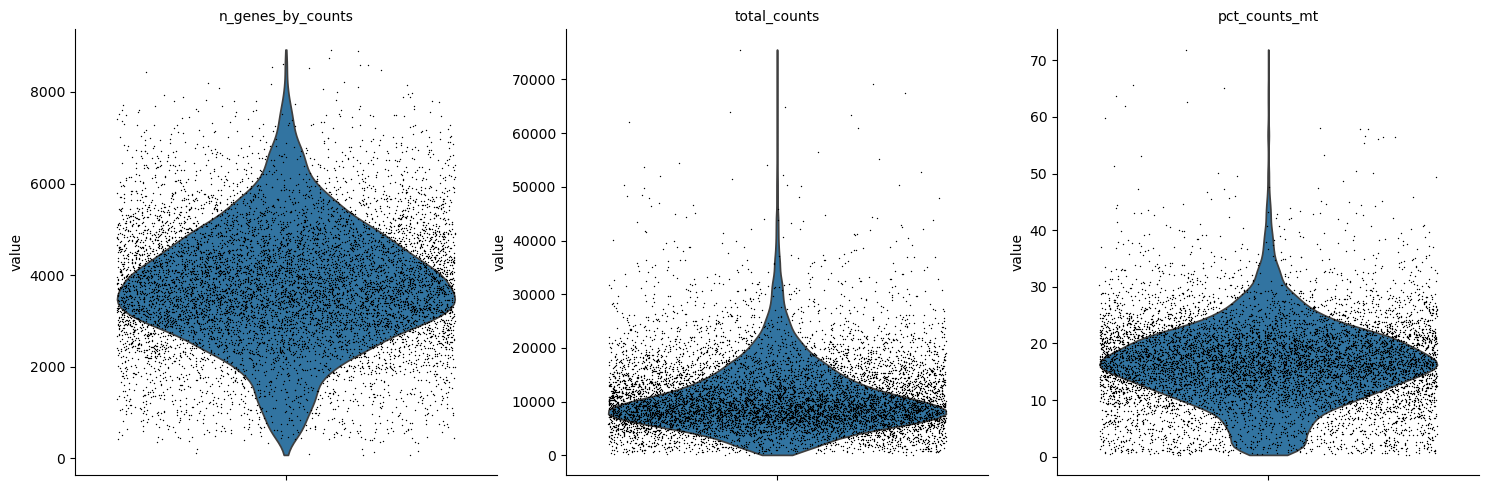

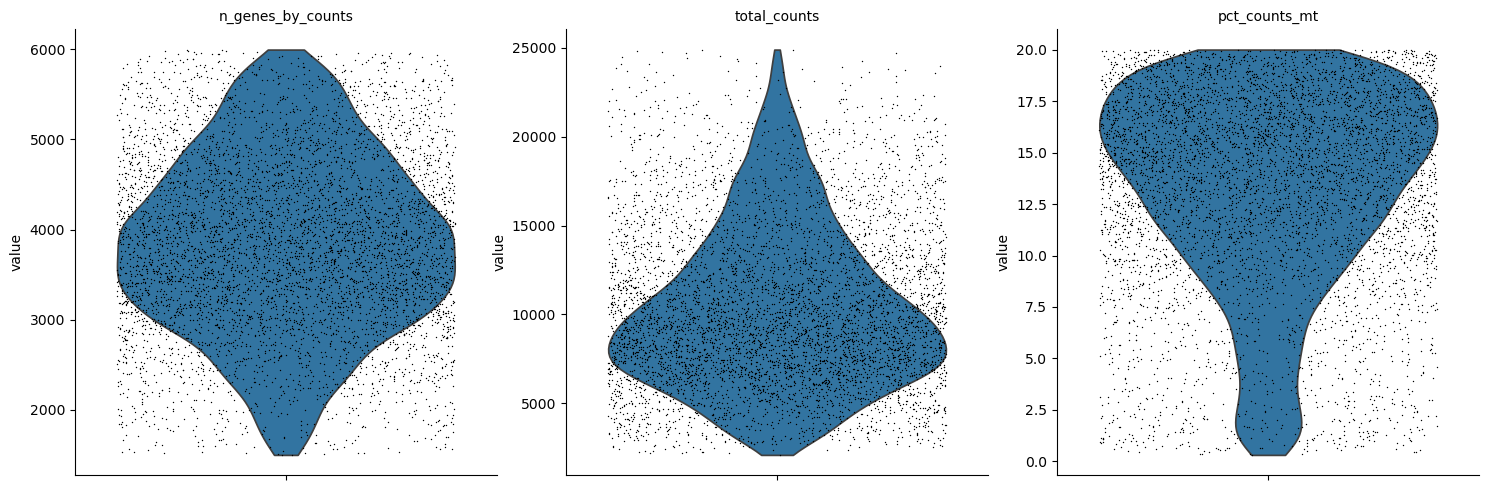

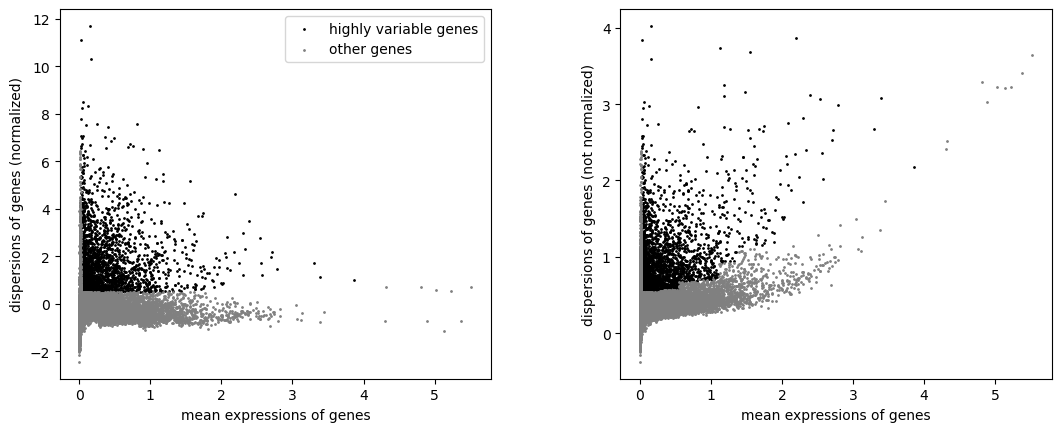

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [7]:
# RNA QC and Preprocessing
data_processor.rna_qc_filter(
    min_cells_per_gene = MIN_CELLS_PER_GENE,
    min_genes_per_cell = MIN_GENES_PER_CELL,
    max_genes_per_cell = MAX_GENES_PER_CELL,
    min_total_counts_per_cell = MIN_TOTAL_COUNTS,
    max_total_counts_per_cell = MAX_TOTAL_COUNTS,
    max_pct_counts_mt = MAX_PCT_COUNTS_MT,
    norm_target_sum = 1e4,
    min_rna_disp = 0.5,
    filter_hvgs = True,
    tf_list_file = None,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "rna_qc",
    )

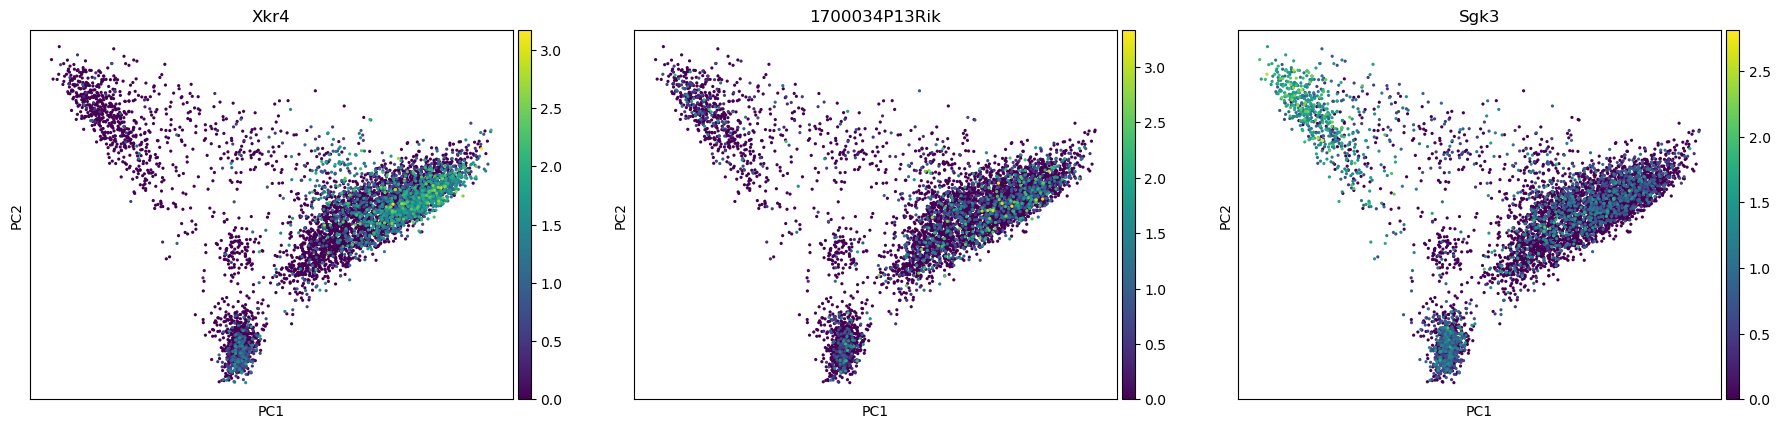

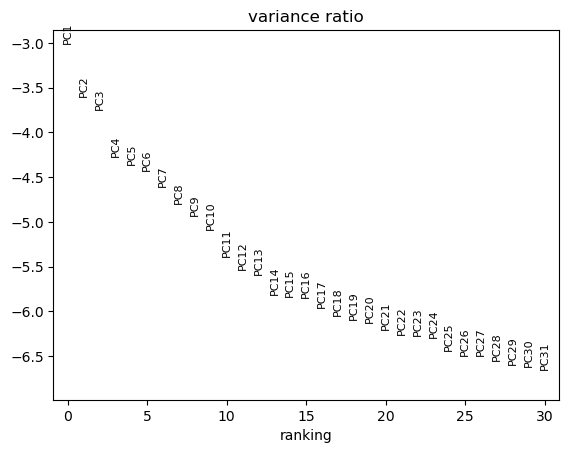

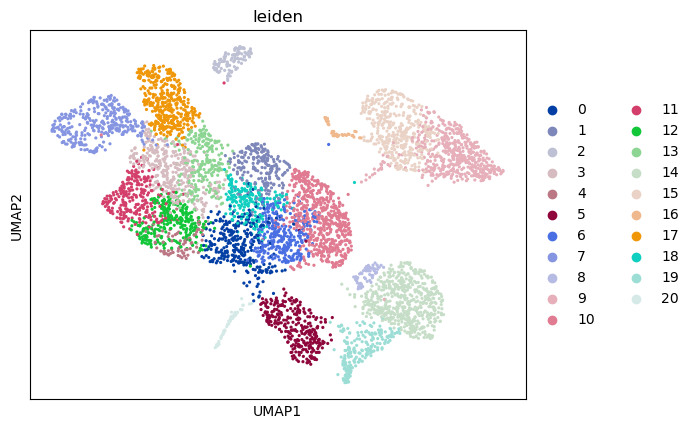

In [ ]:
data_processor.rna_pca_and_neighbors(
    data_processor.rna, 
    n_pcs=10,
    n_neighbors=10,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "rna_qc",
    )

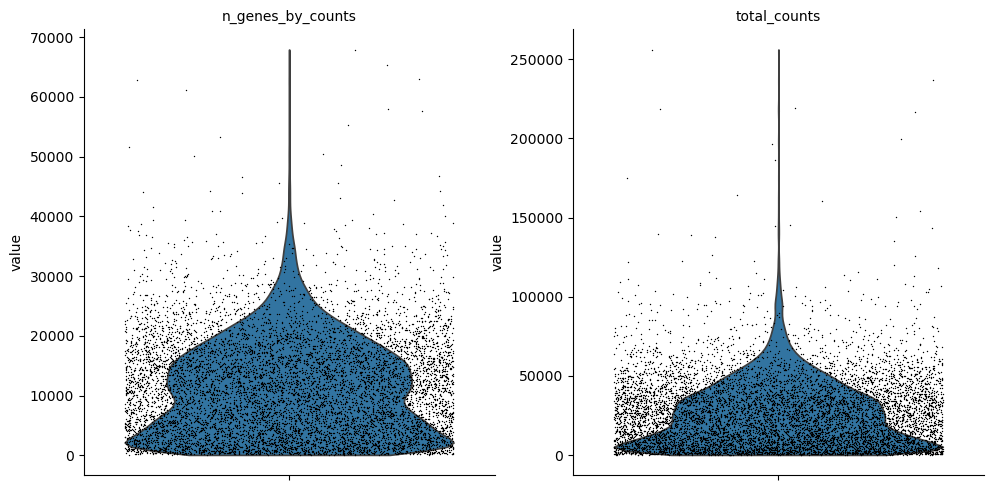

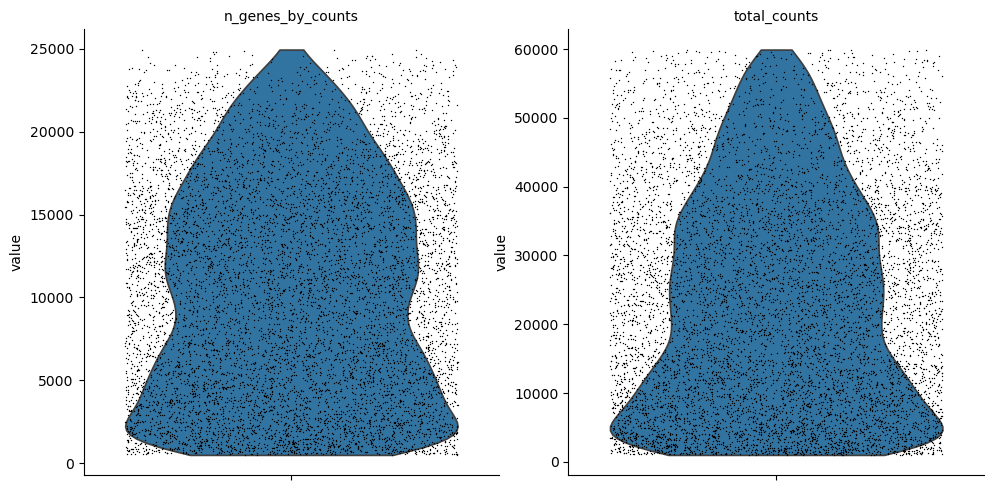

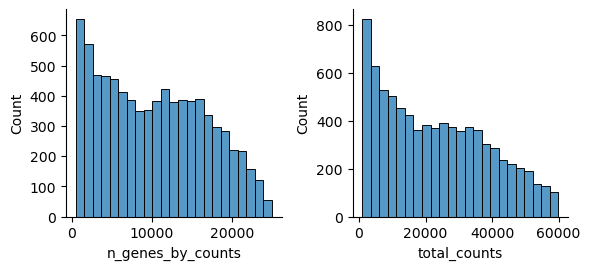

/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/src/multiomic_transformer/utils/muon_preprocessing.py:578: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(self.atac, counts_per_cell_after=scale_factor)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


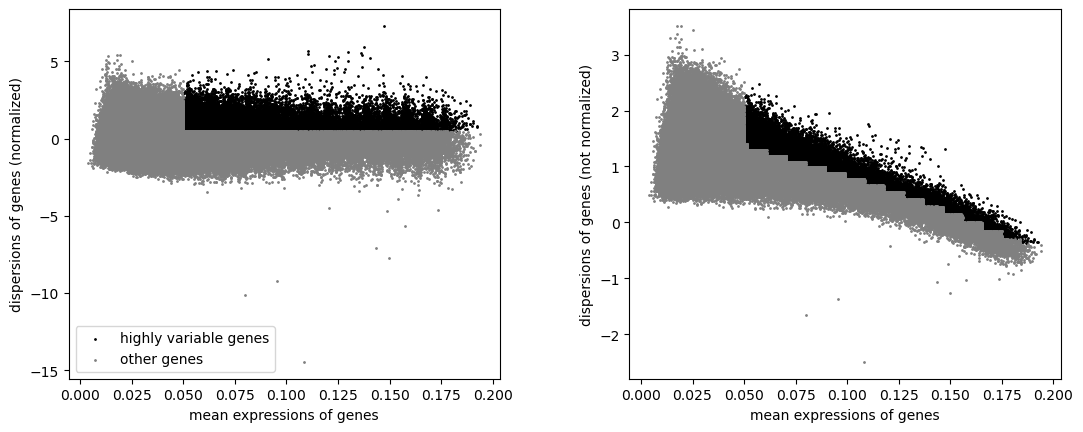

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


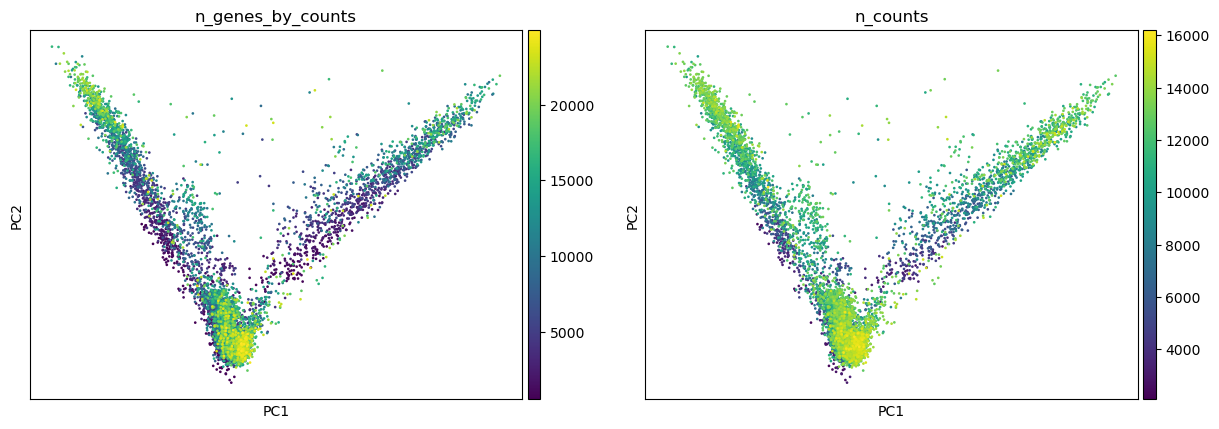

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_atac/tools.py:118: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  pa.loc[pa.distance.isnull(), "distance"] = ""


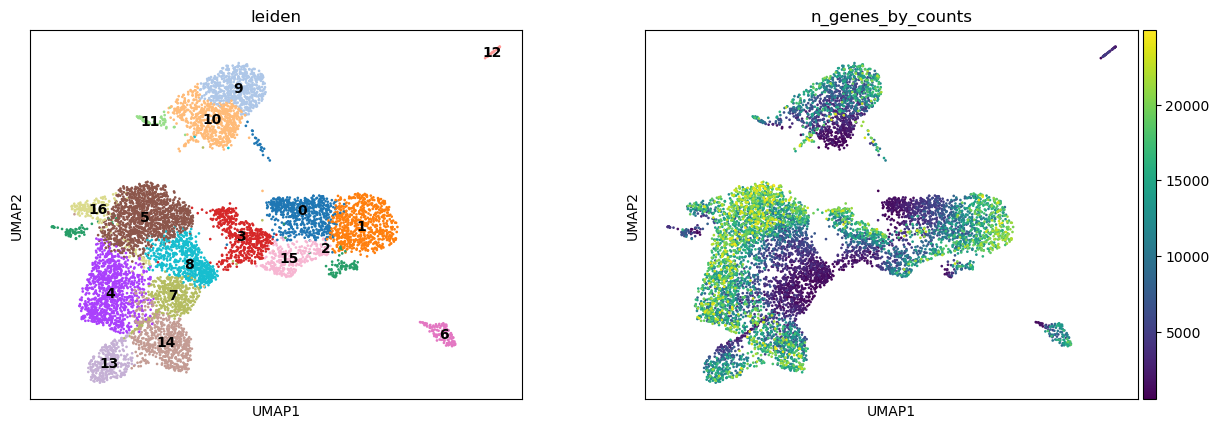

In [9]:
# ATAC QC and Preprocessing
data_processor.atac_qc_filter(
    min_cells_per_peak=MIN_CELLS_PER_PEAK,
    min_peaks_per_cell=MIN_PEAKS_PER_CELL,
    max_peaks_per_cell=MAX_PEAKS_PER_CELL,
    min_total_counts_per_cell=MIN_TOTAL_PEAK_COUNTS,
    max_total_counts_per_cell=MAX_TOTAL_PEAK_COUNTS,
    min_atac_disp=0.5,
    promoter_upstream=1000,
    promoter_downstream=100,
    distal_max=200_000,
    filter_hvgs=False,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "atac_qc",
    )

Found index: /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/RAW_DATA/mESC_10x_raw/E7.5_rep1/fragments.tsv.gz.tbi
['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX']
Fetching Regions...: 100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.70it/s]


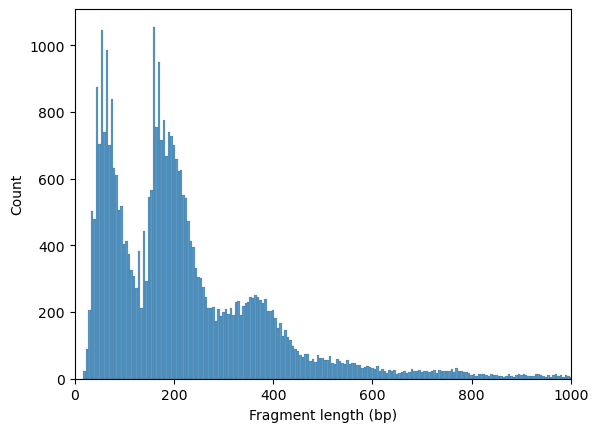

Reading Fragments: 100%|██████████████████████████████████████████████████████| 1000000/1000000 [00:04<00:00, 243539.46it/s]


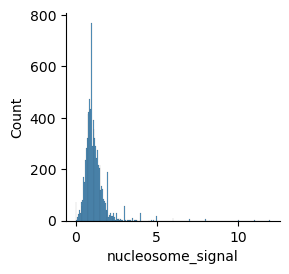

In [10]:
data_processor.nucleosome_signal(
    frag_path=frag_path, 
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "atac_qc"
    )

Fetching Regions...: 100%|██████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 20.57it/s]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


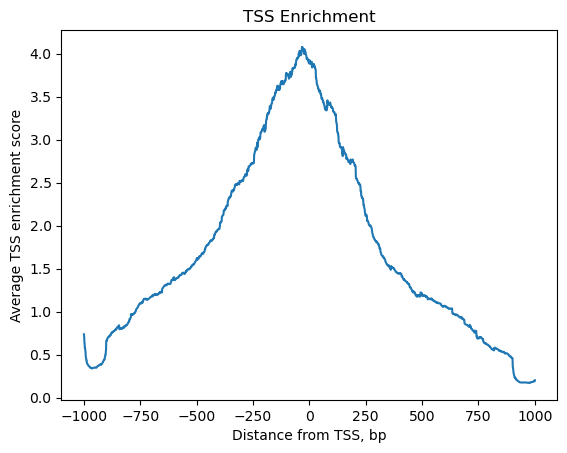

In [11]:
data_processor.tss_enrichment(
    frag_path=frag_path, 
    n_tss=500, 
    extend_upstream=1000, 
    extend_downstream=1000,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "atac_qc"
    )


In [12]:
# Save the processed data
muon_prep.save_processed_data(data_processor.mdata, SAMPLE_PROCESSED_DATA_DIR)

  - rna: kept 2453/2453 features after MOFA precheck
  - atac: kept 199885/199885 features after MOFA precheck
  - post-update dims: RNA=2453, ATAC=199885, total=202338



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Loaded view='rna' group='group1' with N=5199 samples and D=2453 features...
Loaded view='atac' group='group1' with N=5199 samples and D=199885 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
L

... storing 'tss_chrom' as categorical
... storing 'interval' as categorical
... storing 'Chromosome' as categorical


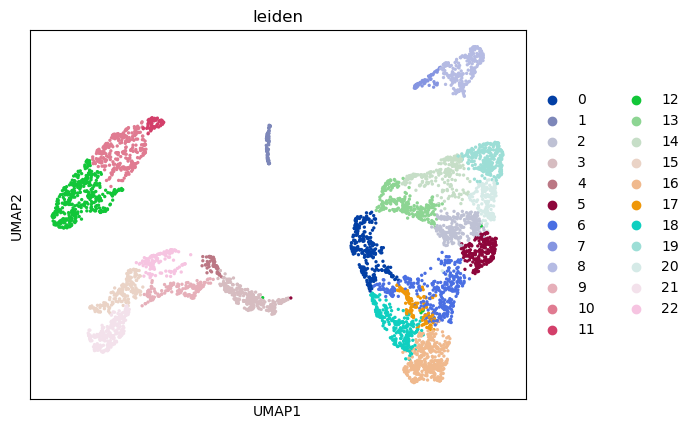

In [13]:
# Integrate the RNA and ATAC modalities using MOFA+
muon_prep.integrate_rna_atac(
    data_processor.mdata, 
    SAMPLE_PROCESSED_DATA_DIR, 
    sample_name, 
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "integration"
    )

In [14]:
# Create metacells
muon_prep.create_metacells(data_processor.mdata, SAMPLE_PROCESSED_DATA_DIR, hops=2)